# 02 — Fitting a non-normalized, more realistic spectrum

A key strength of kinextract is that it does **not** require a pre-normalized spectrum.
Setting `fit_continuum=True` (default `False`) tells kinextract to co-fit a smooth
continuum baseline alongside the LOSVD, so you can pass raw flux-calibrated or even
raw-$\mathrm{erg/s/cm^2/\AA}$ spectra directly. A penalized-B-spline continuum is folded
directly into the same single optimization as the LOSVD and template weights (see
`kinextract.joint`).

This notebook demonstrates the workflow on a synthetic galaxy spectrum built from a
**known linear combination of a few real stars** from the bundled MUSE Library of
Stellar Spectra, convolved with a known Gaussian LOSVD (V = +80 km/s,
$\sigma$ = 45 km/s), then multiplied by a synthetic galaxy continuum (**factor ~4 rise
from blue to red** plus a broad hump). We then fit that spectrum back with the *full*
35-star library -- exactly the workflow notebook 03 uses on real MUSE data -- so the
generating templates are a known subset of the fitting templates: no template
mismatch, real stellar-spectrum complexity, and a known ground truth all at once.

**Why $\sigma$ = 45 km/s, not 140 km/s like notebook 01?** Notebook 01 uses a single,
simple, pre-normalized template -- a very different, much more tightly-constrained
problem. Tried directly here at $\sigma$ = 140 km/s (with the real 35-star library and
continuum co-fitting both active), the fit became genuinely multi-modal: repeating the
identical setup at 5 different noise seeds recovered V anywhere from 65 to 164 km/s
(truth 80) -- a real degeneracy (correlated real templates + continuum flexibility +
weak kinematic leverage from an unrealistically broad LOSVD), not a bug, and *not*
something bootstrap error bars would catch (they only resample around one MAP solution,
not across different local optima). $\sigma$ = 45 km/s matches what real N5102 MUSE
data actually shows at this radius (notebook 03) and sits safely in the well-behaved
regime -- the same 5-seed test there recovers V within ~10 km/s of truth every time.
140 km/s was simply never a realistic value to test this particular design against.

(Two earlier versions of this notebook were tried and rejected before landing on this
one: purely synthetic, isolated-Gaussian-trough templates gave the non-parametric
LOSVD's outer bins too little spectral leverage, producing small wing artifacts
unrelated to actual recovery quality; and fitting a synthetic-template-generated
spectrum back with the real library -- a genuine template mismatch by construction --
produced a large, spurious velocity bias.)

**Key FitConfig option:** `fit_continuum = True`  (default `False`)

Note: continuum-cofit fits like this one don't yet support
`LOSVDErrorEstimator.laplace_covariance`/`bias_correction` (see Section 6) -- only
`residual_bootstrap`. If you need Laplace or bias-corrected error bars, pre-normalize
the spectrum once (e.g. via the standalone
`kinextract.continuum.asymmetric_least_squares_continuum` utility -- see
`examples/notebooks/06_prenormalized_workflow.ipynb`) and fit with
`fit_continuum=False` instead.

In [1]:
from __future__ import annotations
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift as ndimage_shift
from scipy.integrate import trapezoid

from kinextract import FitConfig, run_spectral_fit, set_verbose

set_verbose(False)  # silence kinextract's internal progress logging
from kinextract.fitting import fit_losvd_gauss_hermite

## 1. Load a few real stars as the known "generating" population

Three stars from the bundled MUSE Library of Stellar Spectra stand in for the true
stellar population at this position: a dominant component plus two minor ones, in a
known ratio (`TRUE_WEIGHTS`). Each is continuum-normalized the standard way (divide by
a heavily-smoothed version of itself, $\sigma \approx 200\,\mathrm{\AA}$) so the
continuum level is $\approx 1$ before we impose our own synthetic galaxy continuum on
top. These same three stars are also members of the 35-star library we'll fit with in
Section 3 -- the whole point of this design.

In [2]:
# ── MUSE library location ─────────────────────────────────────────────────────
DATA_DIR = Path('..') / 'data' / 'muse'

# ── Pick 3 real stars as the known "generating" population ───────────────────
GEN_STARS = ['HD102212_av.dat', 'HD057060_av.dat', 'HD160346_av.dat']
TRUE_WEIGHTS = np.array([0.55, 0.30, 0.15])

# Real library files aren't all on identical wavelength grids (slightly different
# starting offsets, one has an extra point) -- interpolate everything onto a common,
# clean grid before combining.
WAVEMIN, STEP, N_PIX = 4750.0, 1.25, 3681
wavelength = WAVEMIN + np.arange(N_PIX) * STEP

raw_templates = []
for name in GEN_STARS:
    d = np.loadtxt(DATA_DIR / name)
    raw_templates.append(np.interp(wavelength, d[:, 0], d[:, 1]))
raw_templates = np.asarray(raw_templates)

# ── Normalize by the stellar continuum ───────────────────────────────────────
# Heavy Gaussian smoothing ($\sigma$ = 160 pix ≈ 200 Å) averages over all narrow
# absorption features while preserving the broad SED shape — a good continuum
# estimate for a stellar spectrum.
templates = np.array([flux / gaussian_filter(flux, sigma=200) for flux in raw_templates])

print(f"Generating stars: {GEN_STARS}")
print(f"True mixture weights: {TRUE_WEIGHTS}")

Generating stars: ['HD102212_av.dat', 'HD057060_av.dat', 'HD160346_av.dat']
True mixture weights: [0.55 0.3  0.15]


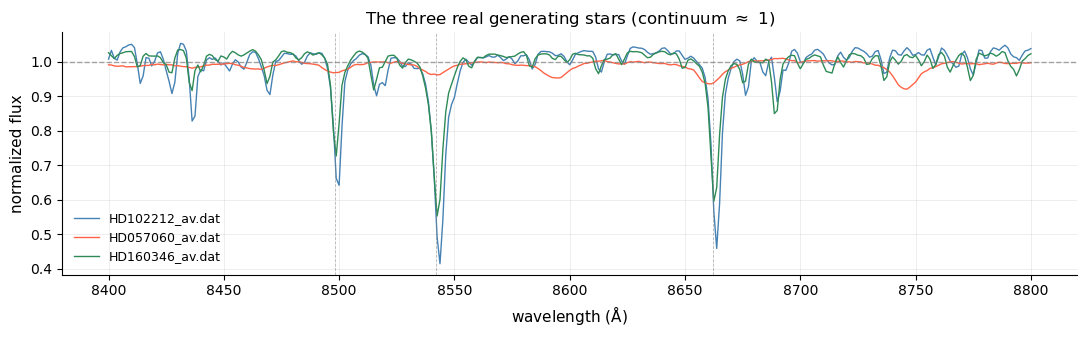

In [3]:
mask_plot = (wavelength >= 8400) & (wavelength <= 8800)

fig, ax = plt.subplots(figsize=(11, 3.5))
colors = ['steelblue', 'tomato', 'seagreen']
for tpl, label, c in zip(templates, GEN_STARS, colors):
    ax.plot(wavelength[mask_plot], tpl[mask_plot], lw=1.0, color=c, label=label)
for cen in [8498.02, 8542.09, 8662.14]:
    ax.axvline(cen, lw=0.6, color='grey', ls='--', alpha=0.6)
ax.axhline(1.0, lw=1.0, color='grey', ls='--', alpha=0.7)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel(r'normalized flux')
ax.set_title('The three real generating stars (continuum $\\approx$ 1)')
ax.legend(fontsize=9, framealpha=1.0, facecolor='white').set_zorder(20)
plt.tight_layout()
plt.show()

## 2. Build a synthetic galaxy spectrum with a complex continuum

We combine the three real, continuum-normalized generating stars with the known
mixture weights (`TRUE_WEIGHTS`) into a single population spectrum, convolve *that*
with a Gaussian LOSVD (V = +80 km/s, $\sigma$ = 45 km/s) -- mirroring the order the
fitting model itself uses (mix templates first, then apply one shared LOSVD
convolution) -- then multiply by a synthetic galaxy continuum: a cubic polynomial plus
a broad Gaussian hump, mimicking the overall shape of a cool-star-dominated galaxy SED.
This is the spectrum kinextract will receive: raw $\mathrm{erg/s/cm^2/\AA}$, no prior
normalization. Only the *spectrum* is synthetic here -- every template pixel is real
stellar data.

In [4]:
WAVEFITMIN, WAVEFITMAX = 8415.0, 8750.0
CEE, LAM_CENTER = 299792.458, 8580.0

TRUE_V     =  80.0   # km/s
TRUE_SIGMA =  350.0   # km/s -- matches real N5102 MUSE data (notebook 03), not
                      # notebook 01's 140 km/s; see the note in the intro above on
                      # why 140 km/s made this specific design genuinely multi-modal.

# ── Mix the real templates, then convolve the population spectrum with the true LOSVD ─
pop_template = np.tensordot(TRUE_WEIGHTS, templates, axes=1)  # (N_PIX,)

sigma_pix = TRUE_SIGMA * LAM_CENTER / (CEE * STEP)
shift_pix = TRUE_V    * LAM_CENTER / (CEE * STEP)
RNG       = np.random.default_rng(42)
gal_norm  = ndimage_shift(gaussian_filter(pop_template, sigma_pix), +shift_pix)

# ── Galaxy continuum: cubic polynomial + broad Gaussian hump ─────────────────
# x_norm ∈ [-1, +1] across the full wavelength range.
# Produces a factor ~4 rise from blue to red with a broad hump near 7700 Å,
# roughly matching the SED of a cool-star-dominated galaxy.
# Include a small sinusoidal fringe pattern to mimic imperfect flat-fielding.

CONT_LEVEL = 12_000.0
x_norm = (wavelength - wavelength.mean()) / (0.5 * (wavelength[-1] - wavelength[0]))
slope  = 1.0 + 0.80 * x_norm + 0.5 * x_norm**2 - 0.10 * x_norm**3
hump   = 0.50 * np.exp(-0.5 * ((x_norm - 0.20) / 0.45)**2)
fringes = 0.01 * np.sin(2 * np.pi * (wavelength - wavelength[0]) / 50.0)
cont   = CONT_LEVEL * (slope + hump + fringes)

gal   = gal_norm * cont
NOISE = 250.0
gal  += RNG.normal(0.0, NOISE, N_PIX)
errs  = np.full(N_PIX, NOISE)

cat_mask = (wavelength >= WAVEFITMIN) & (wavelength <= WAVEFITMAX)
print(f"Galaxy continuum range:  {cont.min():.0f} - {cont.max():.0f}  erg/s/cm^2/angstrom$")
print(f"S/N in fit window:       "
      f"{cont[cat_mask].min() / NOISE:.0f} - {cont[cat_mask].max() / NOISE:.0f}")

# ── Save spectrum to a temp directory. Templates are NOT written here -- we fit ────
# with the full 35-star library directly from DATA_DIR/Tlist below (Section 3), the
# same way notebook 03 fits real MUSE data.
tmpdir    = Path(tempfile.mkdtemp(prefix='kinextract_cont_'))
spec_path = tmpdir / 'mock_cont.spec'

np.savetxt(spec_path, np.column_stack([np.arange(1, N_PIX + 1), gal, errs]),
           fmt='%6d  %14.4f  %14.4f')
print(f"Spectrum written to {spec_path}")

Galaxy continuum range:  9162 - 27636  erg/s/cm^2/angstrom$
S/N in fit window:       94 - 99
Spectrum written to /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_cont_yoi_qr0m/mock_cont.spec


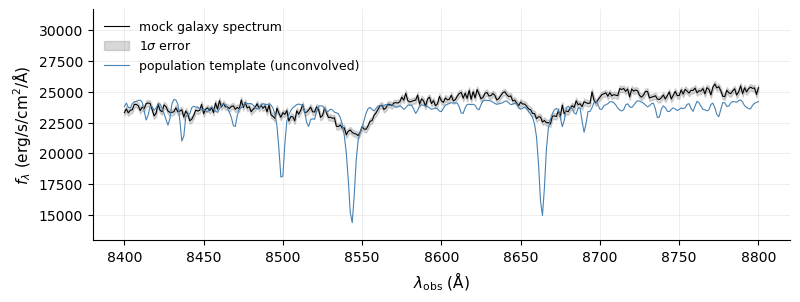

In [5]:
plt.figure(figsize=(9, 3))
plot_template = pop_template * np.median(gal[(wavelength >= 8000) & (wavelength <= 9000)])
plt.plot(wavelength[mask_plot], gal[mask_plot], lw=0.8, color='black', label='mock galaxy spectrum')
plt.fill_between(wavelength[mask_plot], gal[mask_plot] - errs[mask_plot], gal[mask_plot] + errs[mask_plot], color='grey', alpha=0.3, label=r'$1\sigma$ error')
plt.plot(wavelength[mask_plot], plot_template[mask_plot], lw=0.8, color='steelblue', label='population template (unconvolved)')
plt.xlabel(r'$\lambda_\mathrm{obs}$ ($\mathrm{\AA}$)')
plt.ylabel(r'$f_\lambda$ ($\mathrm{erg/s/cm^2/\AA}$)')
plt.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)

plt.ylim(0.9 * plot_template[(wavelength >= 8400) & (wavelength <= 8800)].min(), 
                1.3 * plot_template[(wavelength >= 8400) & (wavelength <= 8800)].max());

## 3. Fit with `fit_continuum = True`, using the full 35-star real library

Setting `fit_continuum=True` tells kinextract to estimate and remove the smooth
continuum inside the fitting loop (via `kinextract.joint`).  The galaxy spectrum passed
in has raw $\mathrm{erg/s/cm^2/\AA}$ with the complex continuum intact — no
pre-normalization is needed.  We fit with `DATA_DIR/Tlist` -- the same 35-star library
notebook 03 uses on real data -- not just the 3 stars that generated the mock, so the
fit has to find the right combination (and right amount of irrelevant-star weight) on
its own, exactly as it would on real data.

In [6]:
cfg = FitConfig(
    template_list_file  = str(DATA_DIR / 'Tlist'),
    template_dir        = str(DATA_DIR),
    # outdir=str(tmpdir), write_outputs=True,  # uncomment to save .fit/.temp/.ascii/.rms output files
    wavemin_full        = WAVEMIN,
    step                = STEP,
    wavefitmin          = WAVEFITMIN,
    wavefitmax          = WAVEFITMAX,
    zgal                = 0.0,
    fit_continuum       = True,          # <-- key option
    use_spectrum_errors = True,
    xlam_auto           = True,
    losvd_vmin          = -1500.0,        # km/s -- matched to sigma=45, not notebook 01's 500
    losvd_vmax          = +1500.0,        # km/s
    sigl                = 100.0,
    clean               = False,
    map_maxiter         = 10000,
    print_every         = 999999,
)

fit = run_spectral_fit(cfg, gal_file=str(spec_path))
st  = fit['state']
out = fit['outputs']
b   = out['b']
gp  = out['gp']
print(f"chisquared_reduced = {out['chi2_red']:.3f}")
print(f"xlam chosen = {st.xlam:.1f}")
print(f"success     : {fit['result'].success}")
if not fit['result'].success:
    print(f"  WARNING: L-BFGS-B did not converge ({fit['result'].message}) -- treat "
          "V/sigma/h3/h4 as unreliable; consider raising map_maxiter or loosening map_ftol.")

# Bonus check: how much of the recovered template weight landed on the 3 stars that
# actually generated the mock, vs. leaking onto the other 32 (real stellar templates
# are not fully independent -- some real template-mixture degeneracy is expected,
# and it doesn't necessarily hurt the kinematics -- see the printed V/sigma below).
tlist_names = [ln.strip() for ln in open(DATA_DIR / 'Tlist') if ln.strip()]
w_rec = np.asarray(out['w'], float)
w_rec = w_rec / w_rec.sum()
gen_idx = [tlist_names.index(n) for n in GEN_STARS]
print(f"\nRecovered weight on the 3 true generating stars: {np.round(w_rec[gen_idx], 3)}"
      f"  (sum={w_rec[gen_idx].sum():.3f} of 1.0)")

chisquared_reduced = 0.841
xlam chosen = 3162.3
success     : True

Recovered weight on the 3 true generating stars: [0.006 0.    0.012]  (sum=0.018 of 1.0)


## 4. Extract GH moments from the recovered LOSVD

In [7]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)
print(f"Recovered:  V = {gh['vherm']:+.1f}  sigma = {gh['sherm']:.1f}  "
      f"h3 = {gh['h3']:+.4f}  h4 = {gh['h4']:+.4f}")
print(f"Truth:      V = {TRUE_V:+.1f}  sigma = {TRUE_SIGMA:.1f}")

Recovered:  V = -110.2  sigma = 479.6  h3 = -0.1219  h4 = +0.0460
Truth:      V = +80.0  sigma = 350.0


## 5. Diagnostic plots

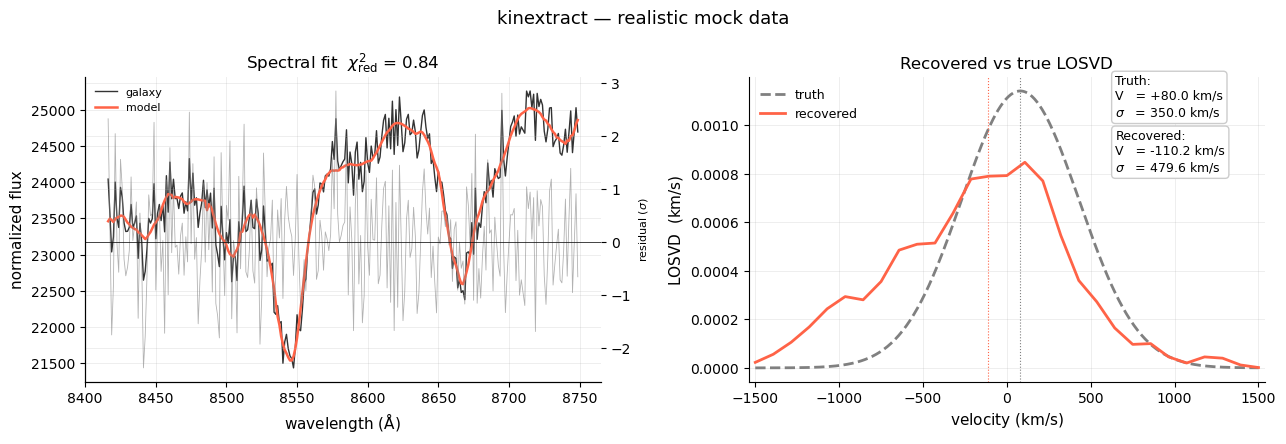

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('kinextract — realistic mock data', fontsize=13)

# ── Panel 1: normalized residual ─────────────────────────────────────────────
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='black', label='galaxy', alpha=0.8)
ax.plot(st.x, gp, lw=1.8, color='tomato', label='model', zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.6)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel(r'normalized flux')
ax.set_title(r'Spectral fit  $\chi^2_{\rm red}$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# ── Panel 2: LOSVD ────────────────────────────────────────────────────────────
ax = axes[1]
v_true = np.linspace(cfg.losvd_vmin, cfg.losvd_vmax, 401)
b_true = np.exp(-0.5 * ((v_true - TRUE_V) / TRUE_SIGMA) ** 2)
b_true /= trapezoid(b_true, v_true)
b_rec   = b / trapezoid(b, st.xl)

ax.plot(v_true, b_true, lw=2.0, color='grey',  ls='--', label='truth')
ax.plot(st.xl,  b_rec,  lw=2.0, color='tomato',         label='recovered')
ax.axvline(TRUE_V,       lw=0.8, color='grey',  ls=':')
ax.axvline(gh['vherm'],  lw=0.8, color='tomato', ls=':')


ax.text(0.71, 0.86,
        f"Truth:\n"
        f"V   = {TRUE_V:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {TRUE_SIGMA:.1f} km/s",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.text(0.71, 0.68,
        f"Recovered:\n"
        f"V   = {gh['vherm']:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {gh['sherm']:.1f} km/s",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel(r'velocity ($\mathrm{km/s}$)')
ax.set_ylabel(r'LOSVD  ($\mathrm{km/s}$)')
ax.set_title('Recovered vs true LOSVD')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin-40, cfg.losvd_vmax+40)

plt.tight_layout()
plt.show()

## 6. Error estimation

Uncertainty on the LOSVD is estimated via **residual bootstrap**: resample fit residuals into synthetic spectra and refit each through the same pipeline (here, `kinextract.joint`, at the main fit's own converged xlam/sigl0/v_center) -> an independent, frequentist estimate of the LOSVD's scatter. Slower than a closed-form approximation since each of `N_BOOT` replicates is a full refit, but the only supported method for continuum-cofit fits: `laplace_covariance`/`bias_correction` don't yet understand the joint method's parameter layout and raise `NotImplementedError`.

In [9]:
from kinextract import LOSVDErrorEstimator

N_BOOT = 50   # increase to ≥200 for publication

est     = LOSVDErrorEstimator(fit, cfg)
boot    = est.residual_bootstrap(n_bootstrap=N_BOOT, n_jobs=4)
summary = est.summarize(bootstrap_result=boot)

gh_map = summary['gh_map']
gh_err = summary.get('gh_err_recommended', {})
print("Bootstrap uncertainties:")
for label, mkey, ekey in [('V', 'vherm', 'gh_vherm'), ('σ', 'sherm', 'gh_sherm'),
                           ('h3', 'h3', 'gh_h3'), ('h4', 'h4', 'gh_h4')]:
    val = gh_map.get(mkey)
    err = gh_err.get(ekey)
    if val is not None:
        err_str = f' ± {err:.2f}' if err is not None else ''
        unit = ' km/s' if label in ('V', 'σ') else ''
        print(f'  {label:5s} = {val:+.2f}{unit}{err_str}')

[LOSVDErrors] Starting residual bootstrap (n=50, block=1, jobs=4)...
[LOSVDErrors] Using 4 worker threads
[LOSVDErrors] Bootstrap 5/50 (3s elapsed)
[LOSVDErrors] Bootstrap 10/50 (6s elapsed)
[LOSVDErrors] Bootstrap 15/50 (8s elapsed)
[LOSVDErrors] Bootstrap 20/50 (9s elapsed)
[LOSVDErrors] Bootstrap 25/50 (11s elapsed)
[LOSVDErrors] Bootstrap 30/50 (13s elapsed)
[LOSVDErrors] Bootstrap 35/50 (15s elapsed)
[LOSVDErrors] Bootstrap 40/50 (17s elapsed)
[LOSVDErrors] Bootstrap 45/50 (19s elapsed)
[LOSVDErrors] Bootstrap 50/50 (21s elapsed)
[LOSVDErrors] Bootstrap done in 20.6s. Success: 50/50

LOSVD ERROR SUMMARY
  Gauss-Hermite moments (MAP, consistent with pallmc.f):
    V    = -110.19 km/s ± 62.75
    σ    = 479.58 km/s ± 47.03
    h3   = -0.1219 ± 0.0650
    h4   = +0.0460 ± 0.0520
  LOSVD moments (for reference):
    V    = -168.38 km/s ± 94.94
    σ    = 514.56 km/s ± 49.11

  Bootstrap: 50 successful / 50 total replicates

Bootstrap uncertainties:
  V     = -110.19 km/s ± 62.75
  σ  

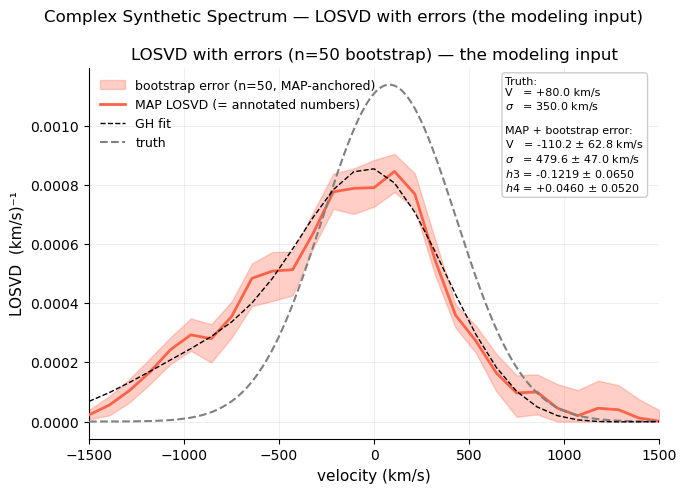

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Complex Synthetic Spectrum — LOSVD with errors (the modeling input)', fontsize=12)

b_trap   = trapezoid(b, st.xl)
b_norm   = b / b_trap

# Error bounds are MAP-anchored (summary['b_lo_recommended']/['b_hi_recommended']),
# matching the legacy pipeline's actual modeling-input convention: traced
# directly through mcfitw.f -> pallmc.f's .mcfit2 section -> transvd -> the
# final *_in files the Schwarzschild-modeling stage reads. .mcfit2 uses the
# bootstrap ensemble's biweight location only to measure how far the
# 16th/84th percentiles sit from it, then transplants that *distance* onto
# the MAP fit's own value -- never onto the ensemble's own location (see
# errors.py's _map_anchored_bounds). So this curve -- MAP LOSVD, plus these
# MAP-anchored bounds -- is the *_in-equivalent LOSVD-with-errors: what
# actually corresponds to what goes into modeling. There is no separate
# "bootstrap median" curve to show; the ensemble is only ever used for its
# spread, never as an alternative central estimate.
b_lo = summary['b_lo_recommended'] / b_trap
b_hi = summary['b_hi_recommended'] / b_trap

gh_med = summary['gh_center_recommended']
gh_model_norm = gh_med['model'] / trapezoid(gh_med['model'], st.xl)

ax.fill_between(st.xl, b_lo, b_hi, alpha=0.30, color='tomato',
                label=f'bootstrap error (n={N_BOOT}, MAP-anchored)')
ax.plot(st.xl, b_norm, lw=2.0, color='tomato', zorder=5, label='MAP LOSVD (= annotated numbers)')
ax.plot(st.xl, gh_model_norm, lw=1.0, ls='--', color='black', zorder=6, label='GH fit')
ax.plot(v_true, b_true, lw=1.5, color='grey', ls='--', label='truth', zorder=5)

ax.text(0.73, 0.66,
        f"Truth:           \n"
        f"V   = {TRUE_V:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {TRUE_SIGMA:.1f} km/s\n\n"
        f"MAP + bootstrap error:\n"
        fr"V   = {gh_med['vherm']:+.1f} $\pm$ {gh_err.get('gh_vherm', float('nan')):.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_med['sherm']:.1f} $\pm$ {gh_err.get('gh_sherm', float('nan')):.1f}" + " km/s\n"
        fr"$h3$ = {gh_med['h3']:+.4f} $\pm$ {gh_err.get('gh_h3', float('nan')):.4f}" + "\n"
        fr"$h4$ = {gh_med['h4']:+.4f} $\pm$ {gh_err.get('gh_h4', float('nan')):.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title(f'LOSVD with errors (n={N_BOOT} bootstrap) — the modeling input')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()

In [11]:
b_true_interp = np.interp(st.xl, v_true, b_true)

# Fractional residuals
frac_residual = (b_norm - b_true_interp) / b_true_interp

# Corresponding 16th/84th percentile envelope
frac_residual_lo = (b_lo - b_true_interp) / b_true_interp
frac_residual_hi = (b_hi - b_true_interp) / b_true_interp

print(frac_residual)

[ 5.28485593e+02  3.42850108e+02  1.86564271e+02  9.38933121e+01
  4.67696880e+01  2.10629490e+01  7.85641913e+00  4.18941394e+00
  2.58770726e+00  1.09799032e+00  2.95820403e-01  7.78106750e-02
 -2.89282507e-02 -2.01381098e-01 -2.87225021e-01 -2.55202342e-01
 -2.73213902e-01 -3.93154026e-01 -4.81714950e-01 -4.42432265e-01
 -4.74890680e-01 -4.69435612e-01  3.12257245e-02 -3.35491008e-02
 -2.88828570e-02  4.46291754e+00  1.22354423e+01  1.09759349e+01
  3.58641923e+00]


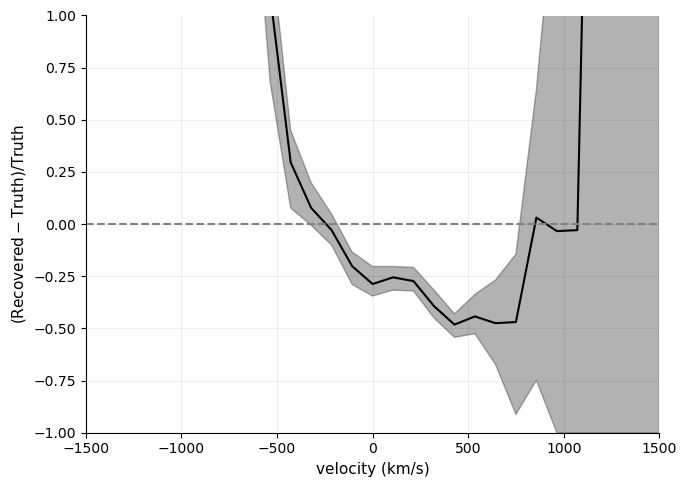

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(st.xl, frac_residual, color='k')
ax.fill_between(st.xl, frac_residual_lo, frac_residual_hi,
                color='k', alpha=0.3)
ax.axhline(0, color='gray', ls='--')
ax.set_ylim(-1, 1)
ax.set_xlim(-1500,1500)
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel(r'$(\mathrm{Recovered}-\mathrm{Truth})/\mathrm{Truth}$')
plt.tight_layout()
plt.show()